### Accelerated Picard algorithm

Known as Steffensen method. Take 2 Picard steps and interpolate. Repeat the process:

\begin{cases}
    x_1 = f(x_0) \\
    x_2 = f(x_1) \\
    x_3 = x_0 - \frac{(x_1 - x_0) ^ 2}{x_2 - 2 \, x_1 + x_0} \\
    x_0 = x_3 \\
    \text{repeat until convergence}
\end{cases}

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def picard_acc(f, x0, *args, N = 100, eps = 1e-06): # Implements the Steffensen method

    j = 0 # Guard
    diff = 1.0 # Absolute error tracker

    while (diff > eps) and (j != N):

        x1 = f(x0, *args) # First step
        x2 = f(x1, *args) # Second step
        den = x2 - 2.0 * x1 + x0 # Denominator

        if abs(den) < 1e-12: # Denominator = 0. Stop

            print(f"Loop terminated: denominator is equal to zero at j = {j}")
            diff = abs(x2 - f(x2, *args))
            return x2, diff

        x3 = x0 - ((x1 - x0) ** 2) / den # Accelerated step
        diff = abs(x3 - f(x3, *args)) # Compute residual of the accelerated value

        if diff < eps: # Precision desired reached. Stop
            print(f"Loop terminated: threshold reached at j = {j}")
            return x3, diff

        # Prepare for next iteration (Steffensen's update)
        x0 = x3
        j += 1

    if j == N: # Max number of iterations reached
        print("Loop terminated: maximum number of iterations reached")

    return x3, diff

Let's apply it to the diode-resistance problem. Given a series diode-resistor circuit, the steady-state voltage drop acros a silicon diode is given implicity by:

$$
    V_{diode} = n \, V_T \, \ln \left(\frac{V_{gen} - V_{diode}}{R \, I_s} + 1 \right)
$$

In this form, the fixed-problem equation can be solved using Picard method (accelerated)

In [3]:
def voltage_diode(V_d, V_g, R, I_s, n, V_T): # Right hand side of the fixed problem equation
    return n * V_T * np.log((V_g - V_d) / (R * I_s) + 1.0)

In [4]:
# Realistic values

V_g = 5.0 # V generator
R = 5_000.0 # Resistance value
I_s = 2.52e-09 # Saturation current
n = 1.75 # Quality factor
V_T = 25.4e-03 # Thermal voltage

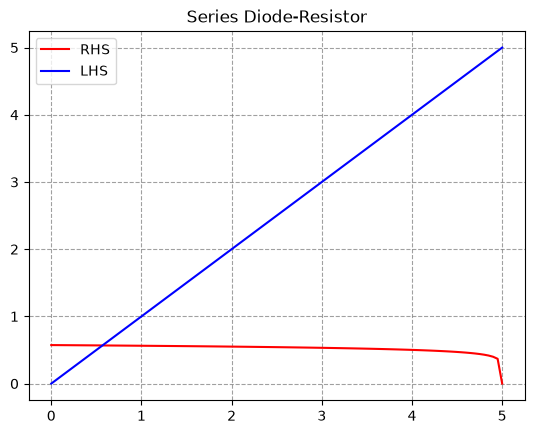

In [5]:
# Plotting to find a suitable starting point
V_d_array = np.linspace(0.0, V_g, 100)
plt.plot(V_d_array, voltage_diode(V_d_array, V_g, R, I_s, n, V_T), label = "RHS", color = 'red')
plt.plot(V_d_array, V_d_array, label = "LHS", color = 'blue')
plt.title('Series Diode-Resistor')
plt.legend(loc = 'best')
plt.grid(True, linestyle = '--', alpha = 0.75, color = 'gray')
plt.show()

In [6]:
x0 = 0.5 # Initial guess
V_d, err_v = picard_acc(voltage_diode, x0, V_g, R, I_s, n, V_T) # V_diode with absolute error [mV]
V_d * (10.0 ** 3), err_v * (10.0 ** 3)

Loop terminated: threshold reached at j = 0


(np.float64(567.6595354505142), np.float64(5.103401434780608e-05))

In [7]:
i, err_i = (V_g - V_d) / R, err_v / R # Current with absolute error (error propagation formula) [uA]
i * (10.0 ** 6), err_i * (10.0 ** 6)

(np.float64(886.4680929098972), np.float64(1.0206802869561216e-05))

Result:

$$
    V_D = 567,65954 \pm 0.00005 \, \, mV \qquad I = 886,46809 \pm 0.00001 \, \, \mu A
$$